In [3]:
import sys
sys.path.insert(0, "..")

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from neural_capm.data.loaders import load_price_series, compute_returns
from neural_capm.finance.rolling_beta import compute_rolling_beta

In [5]:
reliance_prices = load_price_series("RELIANCE.NS")
hdfc_prices = load_price_series("HDFCBANK.NS")
index_prices = load_price_series("^NSEI")

reliance_ret = compute_returns(reliance_prices)
hdfc_ret = compute_returns(hdfc_prices)
index_ret = compute_returns(index_prices)

print(reliance_ret.dtype, hdfc_ret.dtype, index_ret.dtype)

float64 float64 float64


In [6]:
reliance_beta = compute_rolling_beta(reliance_ret, index_ret, window=250)
hdfc_beta = compute_rolling_beta(hdfc_ret, index_ret, window=250)

print(reliance_beta.describe())
print(hdfc_beta.describe())

count    2208.000000
mean        1.095659
std         0.168883
min         0.654869
25%         1.001076
50%         1.108688
75%         1.193524
max         1.505779
Name: rolling_beta, dtype: float64
count    2208.000000
mean        0.959661
std         0.183884
min         0.665361
25%         0.770044
50%         1.013347
75%         1.097989
max         1.306514
Name: rolling_beta, dtype: float64


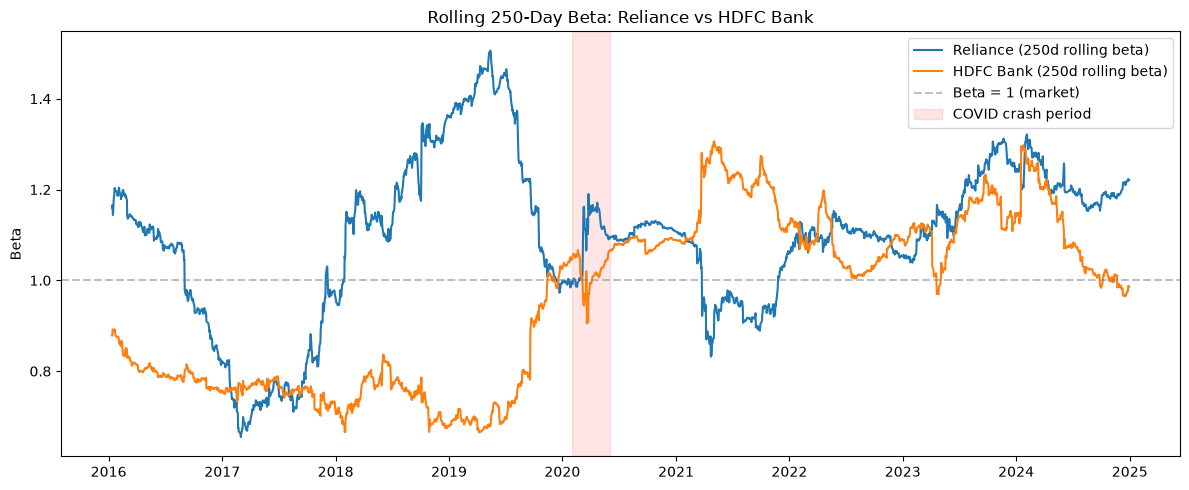

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(reliance_beta.index, reliance_beta.values, label="Reliance (250d rolling beta)")
ax.plot(hdfc_beta.index, hdfc_beta.values, label="HDFC Bank (250d rolling beta)")
ax.axhline(1.0, color="gray", linestyle="--", alpha=0.5, label="Beta = 1 (market)")
ax.axvspan(pd.Timestamp("2020-02-01"), pd.Timestamp("2020-06-01"),
           color="red", alpha=0.1, label="COVID crash period")
ax.set_title("Rolling 250-Day Beta: Reliance vs HDFC Bank")
ax.set_ylabel("Beta")
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
import os
os.makedirs("../results/figures", exist_ok=True)
fig.savefig("../results/figures/rolling_beta_reliance_hdfc.png", dpi=150)
print("saved.")

saved.


In [9]:
from neural_capm.finance.kalman_beta import compute_kalman_beta


In [10]:
reliance_kalman = compute_kalman_beta(reliance_ret, index_ret)
hdfc_kalman = compute_kalman_beta(hdfc_ret, index_ret)

print(reliance_kalman.describe())
print(hdfc_kalman.describe())

count    2457.000000
mean        1.079688
std         0.061308
min         0.926839
25%         1.048213
50%         1.078131
75%         1.123417
max         1.445618
Name: kalman_beta, dtype: float64
count    2457.000000
mean        0.954083
std         0.139177
min         0.565848
25%         0.810615
50%         0.965517
75%         1.088747
max         1.157882
Name: kalman_beta, dtype: float64


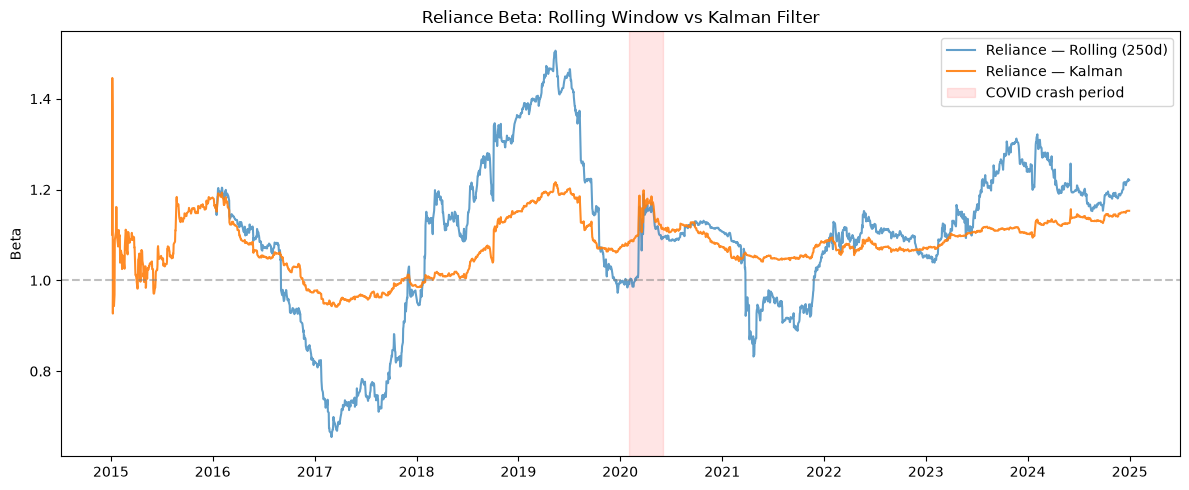

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(reliance_beta.index, reliance_beta.values, label="Reliance — Rolling (250d)", alpha=0.7)
ax.plot(reliance_kalman.index, reliance_kalman.values, label="Reliance — Kalman", alpha=0.9)
ax.axhline(1.0, color="gray", linestyle="--", alpha=0.5)
ax.axvspan(pd.Timestamp("2020-02-01"), pd.Timestamp("2020-06-01"),
           color="red", alpha=0.1, label="COVID crash period")
ax.set_title("Reliance Beta: Rolling Window vs Kalman Filter")
ax.set_ylabel("Beta")
ax.legend()
plt.tight_layout()
plt.show()

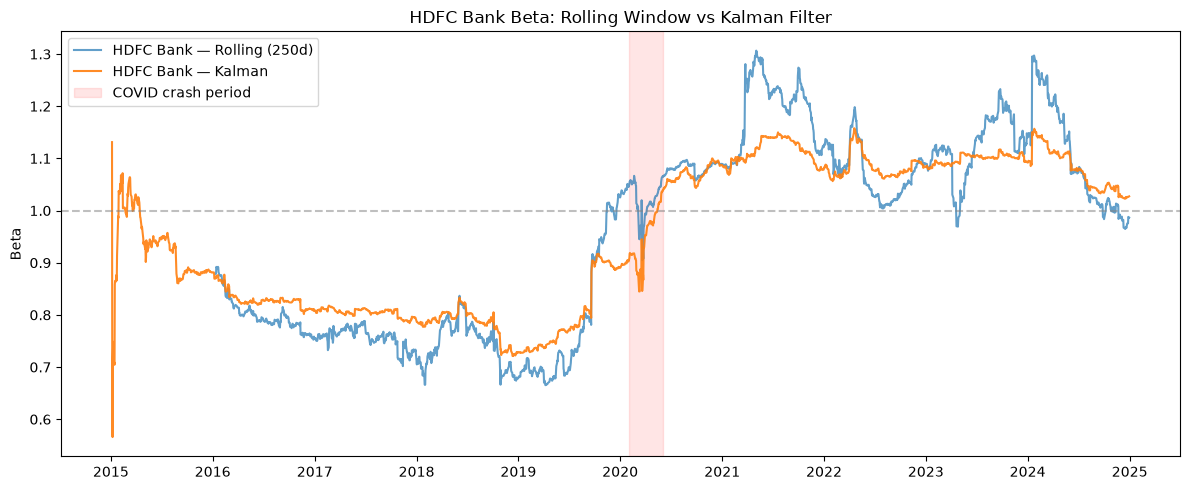

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hdfc_beta.index, hdfc_beta.values, label="HDFC Bank — Rolling (250d)", alpha=0.7)
ax.plot(hdfc_kalman.index, hdfc_kalman.values, label="HDFC Bank — Kalman", alpha=0.9)
ax.axhline(1.0, color="gray", linestyle="--", alpha=0.5)
ax.axvspan(pd.Timestamp("2020-02-01"), pd.Timestamp("2020-06-01"),
           color="red", alpha=0.1, label="COVID crash period")
ax.set_title("HDFC Bank Beta: Rolling Window vs Kalman Filter")
ax.set_ylabel("Beta")
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
import os
os.makedirs("../results/figures", exist_ok=True)
fig.savefig("../results/figures/kalman_vs_rolling_hdfc.png", dpi=150)

In [16]:
burn_in = 90
reliance_kalman_trimmed = reliance_kalman.iloc[burn_in:]
hdfc_kalman_trimmed = hdfc_kalman.iloc[burn_in:]

print("Before trim:", reliance_kalman.index[0])
print("After trim: ", reliance_kalman_trimmed.index[0])

Before trim: 2015-01-05 00:00:00
After trim:  2015-05-21 00:00:00


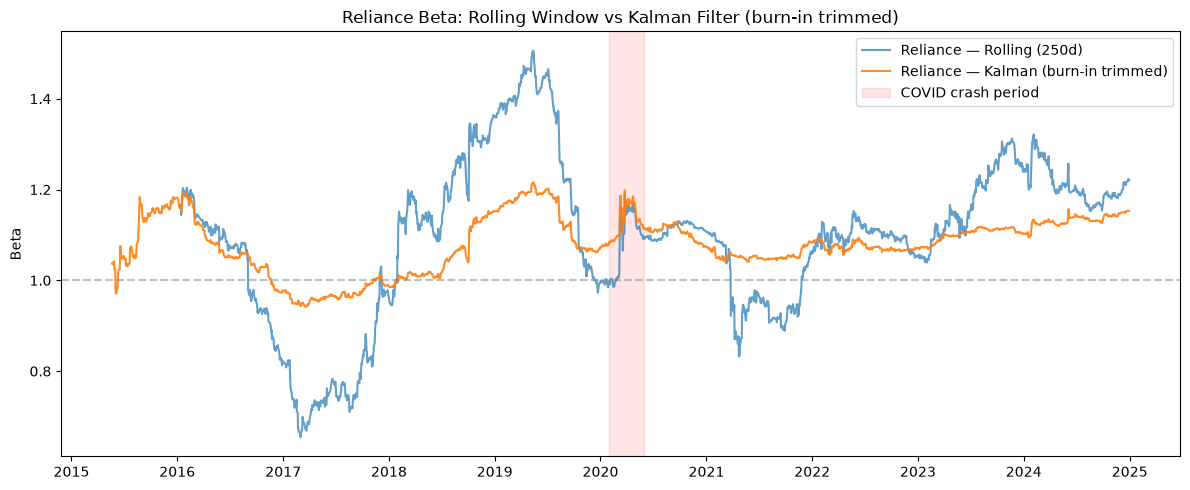

In [17]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(reliance_beta.index, reliance_beta.values, label="Reliance — Rolling (250d)", alpha=0.7)
ax.plot(reliance_kalman_trimmed.index, reliance_kalman_trimmed.values, label="Reliance — Kalman (burn-in trimmed)", alpha=0.9)
ax.axhline(1.0, color="gray", linestyle="--", alpha=0.5)
ax.axvspan(pd.Timestamp("2020-02-01"), pd.Timestamp("2020-06-01"),
           color="red", alpha=0.1, label="COVID crash period")
ax.set_title("Reliance Beta: Rolling Window vs Kalman Filter (burn-in trimmed)")
ax.set_ylabel("Beta")
ax.legend()
plt.tight_layout()
plt.show()

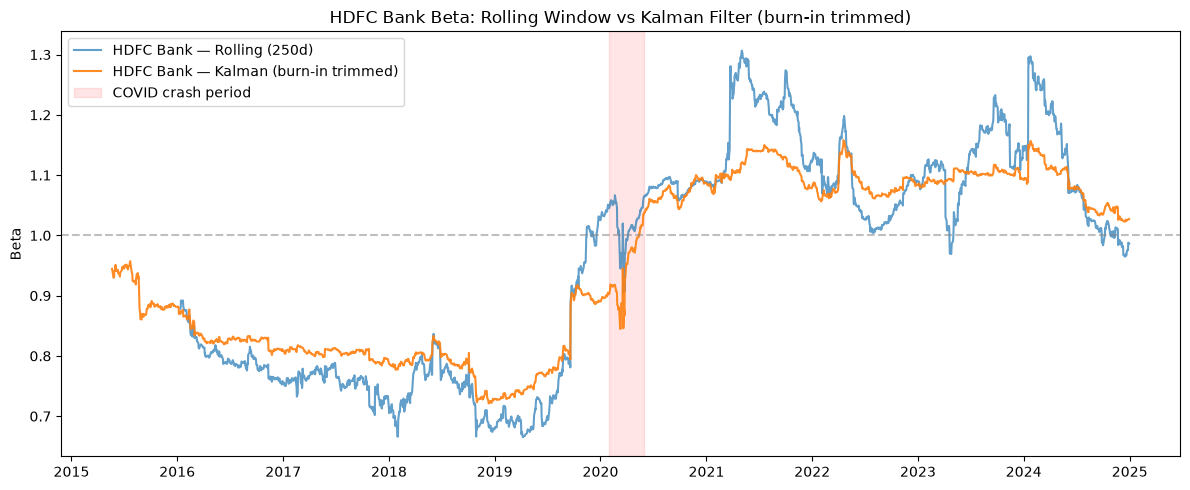

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hdfc_beta.index, hdfc_beta.values, label="HDFC Bank — Rolling (250d)", alpha=0.7)
ax.plot(hdfc_kalman_trimmed.index, hdfc_kalman_trimmed.values, label="HDFC Bank — Kalman (burn-in trimmed)", alpha=0.9)
ax.axhline(1.0, color="gray", linestyle="--", alpha=0.5)
ax.axvspan(pd.Timestamp("2020-02-01"), pd.Timestamp("2020-06-01"),
           color="red", alpha=0.1, label="COVID crash period")
ax.set_title("HDFC Bank Beta: Rolling Window vs Kalman Filter (burn-in trimmed)")
ax.set_ylabel("Beta")
ax.legend()
plt.tight_layout()
plt.show()

saved both figures.


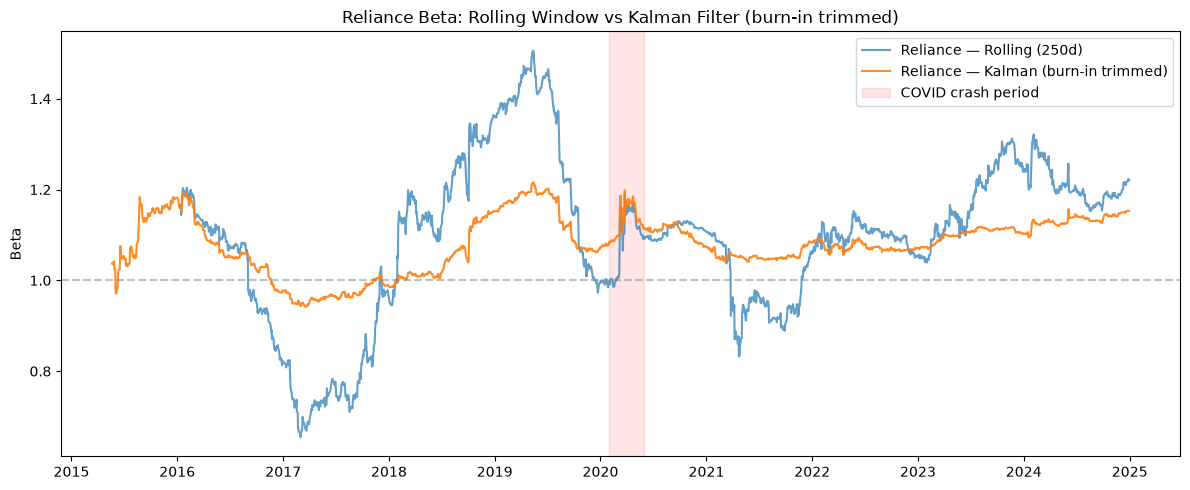

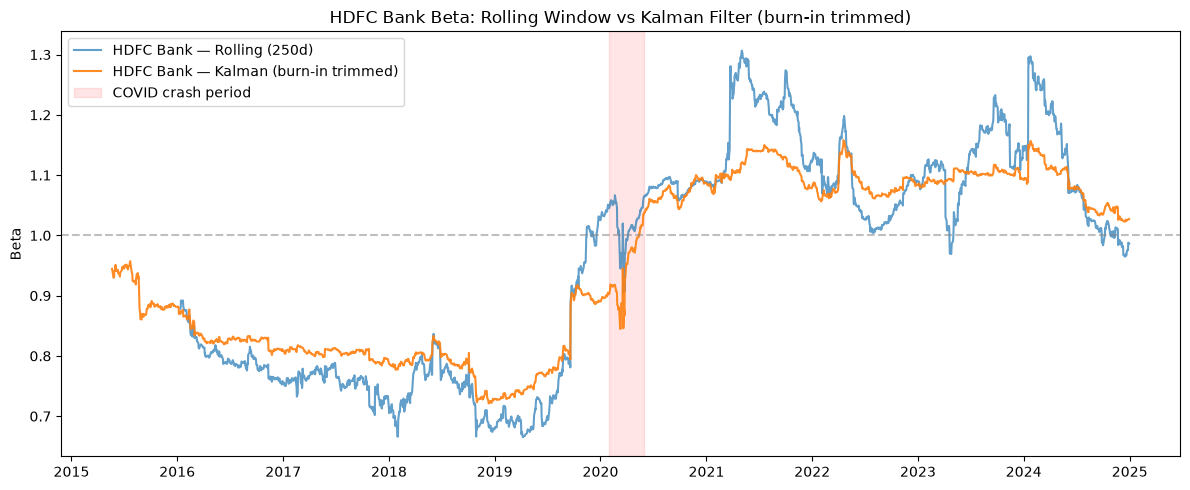

In [19]:
import os
os.makedirs("../results/figures", exist_ok=True)

fig_reliance, ax = plt.subplots(figsize=(12, 5))
ax.plot(reliance_beta.index, reliance_beta.values, label="Reliance — Rolling (250d)", alpha=0.7)
ax.plot(reliance_kalman_trimmed.index, reliance_kalman_trimmed.values, label="Reliance — Kalman (burn-in trimmed)", alpha=0.9)
ax.axhline(1.0, color="gray", linestyle="--", alpha=0.5)
ax.axvspan(pd.Timestamp("2020-02-01"), pd.Timestamp("2020-06-01"), color="red", alpha=0.1, label="COVID crash period")
ax.set_title("Reliance Beta: Rolling Window vs Kalman Filter (burn-in trimmed)")
ax.set_ylabel("Beta")
ax.legend()
plt.tight_layout()
fig_reliance.savefig("../results/figures/kalman_vs_rolling_reliance.png", dpi=150)

fig_hdfc, ax = plt.subplots(figsize=(12, 5))
ax.plot(hdfc_beta.index, hdfc_beta.values, label="HDFC Bank — Rolling (250d)", alpha=0.7)
ax.plot(hdfc_kalman_trimmed.index, hdfc_kalman_trimmed.values, label="HDFC Bank — Kalman (burn-in trimmed)", alpha=0.9)
ax.axhline(1.0, color="gray", linestyle="--", alpha=0.5)
ax.axvspan(pd.Timestamp("2020-02-01"), pd.Timestamp("2020-06-01"), color="red", alpha=0.1, label="COVID crash period")
ax.set_title("HDFC Bank Beta: Rolling Window vs Kalman Filter (burn-in trimmed)")
ax.set_ylabel("Beta")
ax.legend()
plt.tight_layout()
fig_hdfc.savefig("../results/figures/kalman_vs_rolling_hdfc.png", dpi=150)

print("saved both figures.")

Q Sensitivity Experiment 

In [20]:
Q_values = {"low (1e-6)": 1e-6, "default (1e-5)": 1e-5, "high (1e-3)": 1e-3}

reliance_kalman_by_q = {
    label: compute_kalman_beta(reliance_ret, index_ret, Q=q).iloc[burn_in:]
    for label, q in Q_values.items()
}

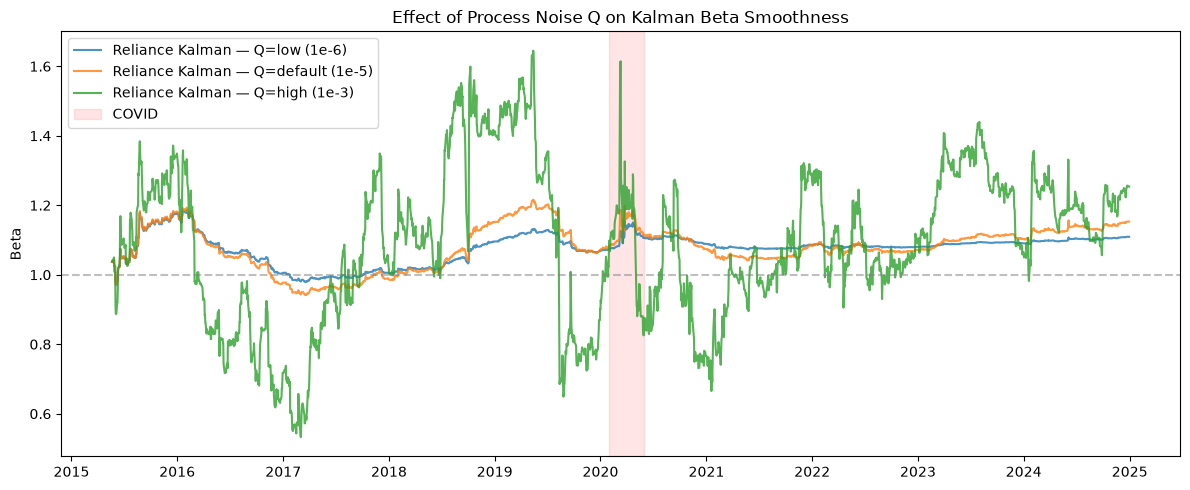

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))
for label, series in reliance_kalman_by_q.items():
    ax.plot(series.index, series.values, label=f"Reliance Kalman — Q={label}", alpha=0.8)
ax.axhline(1.0, color="gray", linestyle="--", alpha=0.5)
ax.axvspan(pd.Timestamp("2020-02-01"), pd.Timestamp("2020-06-01"), color="red", alpha=0.1, label="COVID")
ax.set_title("Effect of Process Noise Q on Kalman Beta Smoothness")
ax.set_ylabel("Beta")
ax.legend()
plt.tight_layout()
plt.savefig("../results/figures/kalman_q_sensitivity.png", dpi=150)
plt.show()